<a href="https://colab.research.google.com/github/mgomez3004/datasciencemariog/blob/main/Actividad_3_Mario_Gomez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
"""
=============================================================
 ANÁLISIS EXPLORATORIO — Predictive Maintenance Dataset
 Kaggle: https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification
=============================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from google.colab import files

uploaded = files.upload()
df=pd.read_csv('predictive_maintenance.csv')

# ── Estilo global ─────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = ["#2196F3", "#F44336", "#FF9800", "#4CAF50", "#9C27B0", "#00BCD4"]
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
})


Saving predictive_maintenance.csv to predictive_maintenance (4).csv


In [36]:

# ══════════════════════════════════════════════════════════
# 1. CARGA DEL DATASET
# ══════════════════════════════════════════════════════════
df = pd.read_csv("predictive_maintenance.csv")


print("  1. EXPLORACIÓN INICIAL")
print(f"\n📐 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print("\n📋 Primeras 5 filas:")
print(df.head())
print("\n📊 Tipos de datos:")
print(df.dtypes)
print("\n🔍 Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n👯 Duplicados exactos: {df.duplicated().sum()}")
print("\n📈 Estadísticas descriptivas (columnas numéricas):")
print(df.describe().round(2))


  1. EXPLORACIÓN INICIAL

📐 Dimensiones: 10,000 filas × 10 columnas

📋 Primeras 5 filas:
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Target Failure Type  
0                    1551         42.8                0       0   No Failure  
1                    1408         46.3                3       0   No Failure  
2                    1498         49.4                5       0   No Failure  
3                    1433         39.5                7       0   No Failure  
4                    1408         40.0                9       0   No Failure  

📊 T

In [37]:

# ══════════════════════════════════════════════════════════
# 2. LIMPIEZA DE DATOS
# ══════════════════════════════════════════════════════════

print("  2. LIMPIEZA DE DATOS")


# Renombrar columnas para mayor comodidad
df.columns = [
    "UDI", "Product_ID", "Type", "Air_Temp_K", "Process_Temp_K",
    "Rot_Speed_rpm", "Torque_Nm", "Tool_Wear_min", "Target", "Failure_Type"
]

# No hay nulos ni duplicados — se documenta la decisión
print("✅ Sin valores nulos ni duplicados: no se requiere dropna/fillna.")

# Estandarizar texto en columna categórica
df["Failure_Type"] = df["Failure_Type"].str.strip()
df["Type"] = df["Type"].str.strip()

# Eliminar columnas no útiles para el análisis
df.drop(columns=["UDI", "Product_ID"], inplace=True)
print(f"✅ Columnas 'UDI' y 'Product_ID' eliminadas (solo son identificadores).")


  2. LIMPIEZA DE DATOS
✅ Sin valores nulos ni duplicados: no se requiere dropna/fillna.
✅ Columnas 'UDI' y 'Product_ID' eliminadas (solo son identificadores).


In [40]:

# ══════════════════════════════════════════════════════════
# 3. TRANSFORMACIÓN Y NUEVAS VARIABLES
# ══════════════════════════════════════════════════════════

print("  3. TRANSFORMACIÓN Y NUEVAS VARIABLES")


# Diferencia de temperatura (indicador de disipación de calor)
df["Temp_Diff_K"] = df["Process_Temp_K"] - df["Air_Temp_K"]

# Potencia mecánica: W = torque × velocidad angular (rad/s)
df["Power_W"] = df["Torque_Nm"] * (df["Rot_Speed_rpm"] * 2 * np.pi / 60)

# Etiqueta legible del tipo de máquina
type_map = {"L": "Low Quality", "M": "Medium Quality", "H": "High Quality"}
df["Type_Label"] = df["Type"].map(type_map)

# Nivel de desgaste de herramienta (terciles)
df["Wear_Level"] = pd.cut(
    df["Tool_Wear_min"],
    bins=[-1, 80, 160, 250],
    labels=["Bajo (0–80)", "Medio (80–160)", "Alto (>160)"]
)

# Indicador binario de falla
df["Failed"] = (df["Target"] == 1).astype(int)

print("✅ Nuevas columnas creadas:")
for col in ["Temp_Diff_K", "Power_W", "Type_Label", "Wear_Level", "Failed"]:
    print(f"   • {col}")



  3. TRANSFORMACIÓN Y NUEVAS VARIABLES
✅ Nuevas columnas creadas:
   • Temp_Diff_K
   • Power_W
   • Type_Label
   • Wear_Level
   • Failed


In [41]:
# ══════════════════════════════════════════════════════════
# 4. FILTRADO Y SELECCIÓN DE DATOS RELEVANTES
# ══════════════════════════════════════════════════════════

print("  4. FILTRADO Y SELECCIÓN")

fallas = df[df["Failed"] == 1].copy()
sin_falla = df[df["Failed"] == 0].copy()
print(f"✅ Registros con falla:     {len(fallas):,}  ({len(fallas)/len(df)*100:.1f}%)")
print(f"✅ Registros sin falla:     {len(sin_falla):,}  ({len(sin_falla)/len(df)*100:.1f}%)")



  4. FILTRADO Y SELECCIÓN
✅ Registros con falla:     339  (3.4%)
✅ Registros sin falla:     9,661  (96.6%)


In [42]:

# ══════════════════════════════════════════════════════════
# 5. AGRUPACIONES Y RESÚMENES
# ══════════════════════════════════════════════════════════

print("  5. AGRUPACIONES Y RESÚMENES (groupby)")


# Por tipo de máquina
resumen_tipo = df.groupby("Type_Label").agg(
    Maquinas=("Failed", "count"),
    Fallas=("Failed", "sum"),
    Tasa_Falla_pct=("Failed", lambda x: round(x.mean()*100, 2)),
    Desgaste_Prom_min=("Tool_Wear_min", "mean"),
    Torque_Prom_Nm=("Torque_Nm", "mean"),
).reset_index()
print("\nResumen por tipo de máquina:")
print(resumen_tipo.to_string(index=False))

# Por tipo de falla
resumen_falla = df.groupby("Failure_Type").agg(
    Casos=("Failed", "count"),
    Torque_Prom=("Torque_Nm", "mean"),
    Desgaste_Prom=("Tool_Wear_min", "mean"),
    Power_Prom_W=("Power_W", "mean"),
).reset_index().sort_values("Casos", ascending=False)
print("\nResumen por tipo de falla:")
print(resumen_falla.to_string(index=False))

# Por nivel de desgaste
resumen_desgaste = df.groupby("Wear_Level", observed=True).agg(
    Casos=("Failed", "count"),
    Fallas=("Failed", "sum"),
    Tasa_Falla_pct=("Failed", lambda x: round(x.mean()*100, 2)),
).reset_index()
print("\nResumen por nivel de desgaste:")
print(resumen_desgaste.to_string(index=False))



  5. AGRUPACIONES Y RESÚMENES (groupby)

Resumen por tipo de máquina:
    Type_Label  Maquinas  Fallas  Tasa_Falla_pct  Desgaste_Prom_min  Torque_Prom_Nm
  High Quality      1003      21            2.09         107.419741       39.838285
   Low Quality      6000     235            3.92         108.378833       39.996600
Medium Quality      2997      83            2.77         107.272272       40.017251

Resumen por tipo de falla:
            Failure_Type  Casos  Torque_Prom  Desgaste_Prom  Power_Prom_W
              No Failure   9652    39.624316     106.678927   6243.934195
Heat Dissipation Failure    112    52.778571     107.339286   7383.502141
           Power Failure     95    48.514737     101.884211   7251.822098
      Overstrain Failure     78    56.878205     208.217949   8043.054092
       Tool Wear Failure     45    37.226667     216.555556   5945.815490
         Random Failures     18    43.522222     119.888889   6677.857193

Resumen por nivel de desgaste:
    Wear_Level  

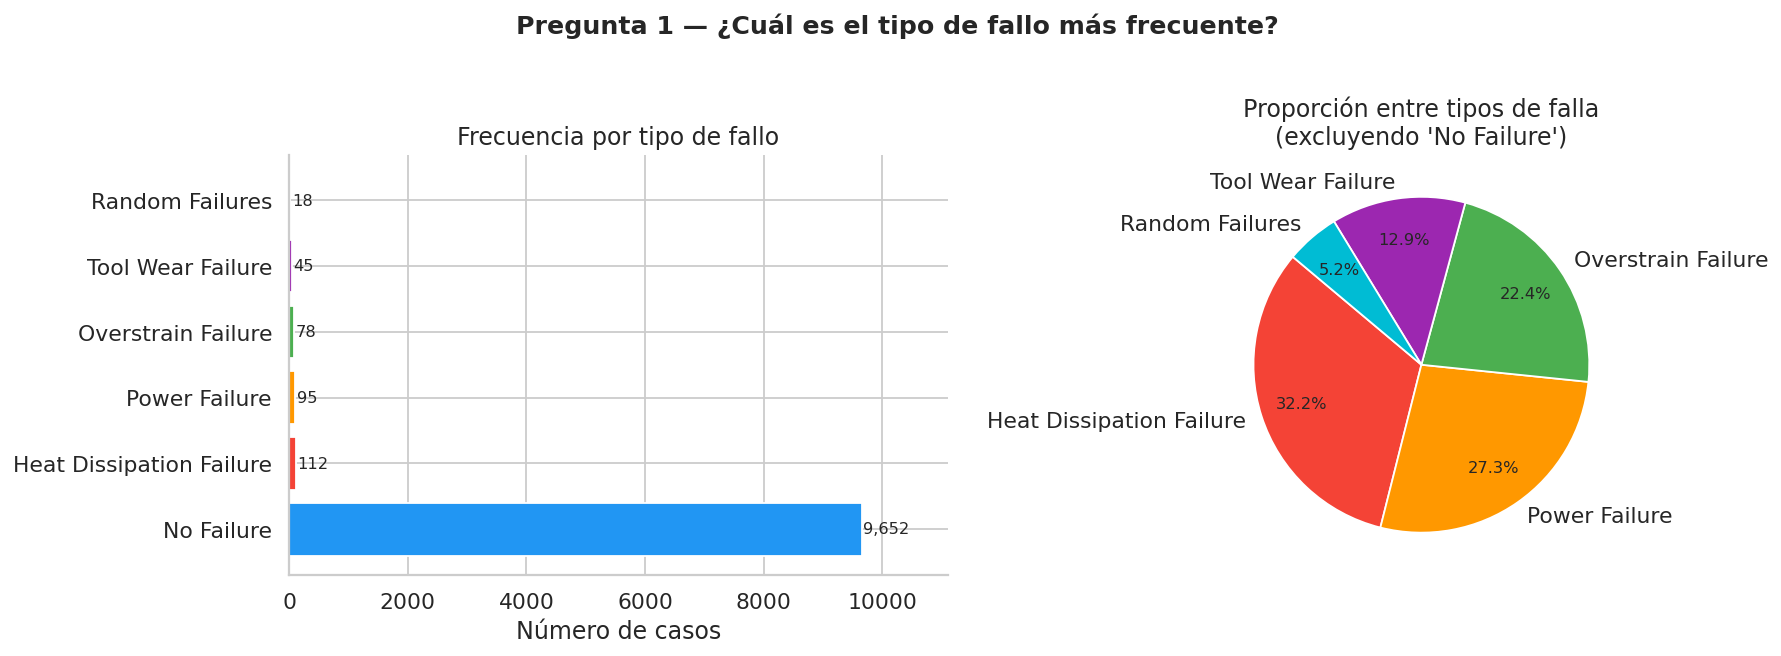


✅ Gráfica P1 guardada.


In [30]:

# ══════════════════════════════════════════════════════════
# PREGUNTAS DE ANÁLISIS — VISUALIZACIONES
# ══════════════════════════════════════════════════════════

fig_titles = [
    "P1 — Distribución de tipos de fallo",
    "P2 — ¿Qué tipo de máquina falla más?",
    "P3 — ¿Hay valores atípicos en variables numéricas?",
    "P4 — ¿Cómo influye el desgaste de herramienta en las fallas?",
    "P5 — ¿Existe relación entre velocidad, torque y fallo?",
]

# ─────────────────────────────────────────────────────────
# PREGUNTA 1
# ¿Cuál es el tipo de fallo más frecuente y cómo se distribuye?
# ─────────────────────────────────────────────────────────
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))
fig1.suptitle(
    "Pregunta 1 — ¿Cuál es el tipo de fallo más frecuente?",
    fontsize=14, fontweight="bold", y=1.01
)

counts = df["Failure_Type"].value_counts()

# Barras
bars = axes1[0].barh(counts.index, counts.values, color=PALETTE, edgecolor="white")
axes1[0].set_xlabel("Número de casos")
axes1[0].set_title("Frecuencia por tipo de fallo")
for bar in bars:
    w = bar.get_width()
    axes1[0].text(w + 30, bar.get_y() + bar.get_height()/2,
                  f"{w:,}", va="center", fontsize=9)
axes1[0].set_xlim(0, counts.max() * 1.15)

# Torta solo con los tipos de falla (sin "No Failure")
fallas_solo = counts.drop("No Failure")
wedges, texts, autotexts = axes1[1].pie(
    fallas_solo.values,
    labels=fallas_solo.index,
    autopct="%1.1f%%",
    colors=PALETTE[1:],
    startangle=140,
    pctdistance=0.75,
)
for t in autotexts:
    t.set_fontsize(9)
axes1[1].set_title("Proporción entre tipos de falla\n(excluyendo 'No Failure')")

plt.tight_layout()
plt.tight_layout()
plt.show()
print("\n✅ Gráfica P1 guardada.")


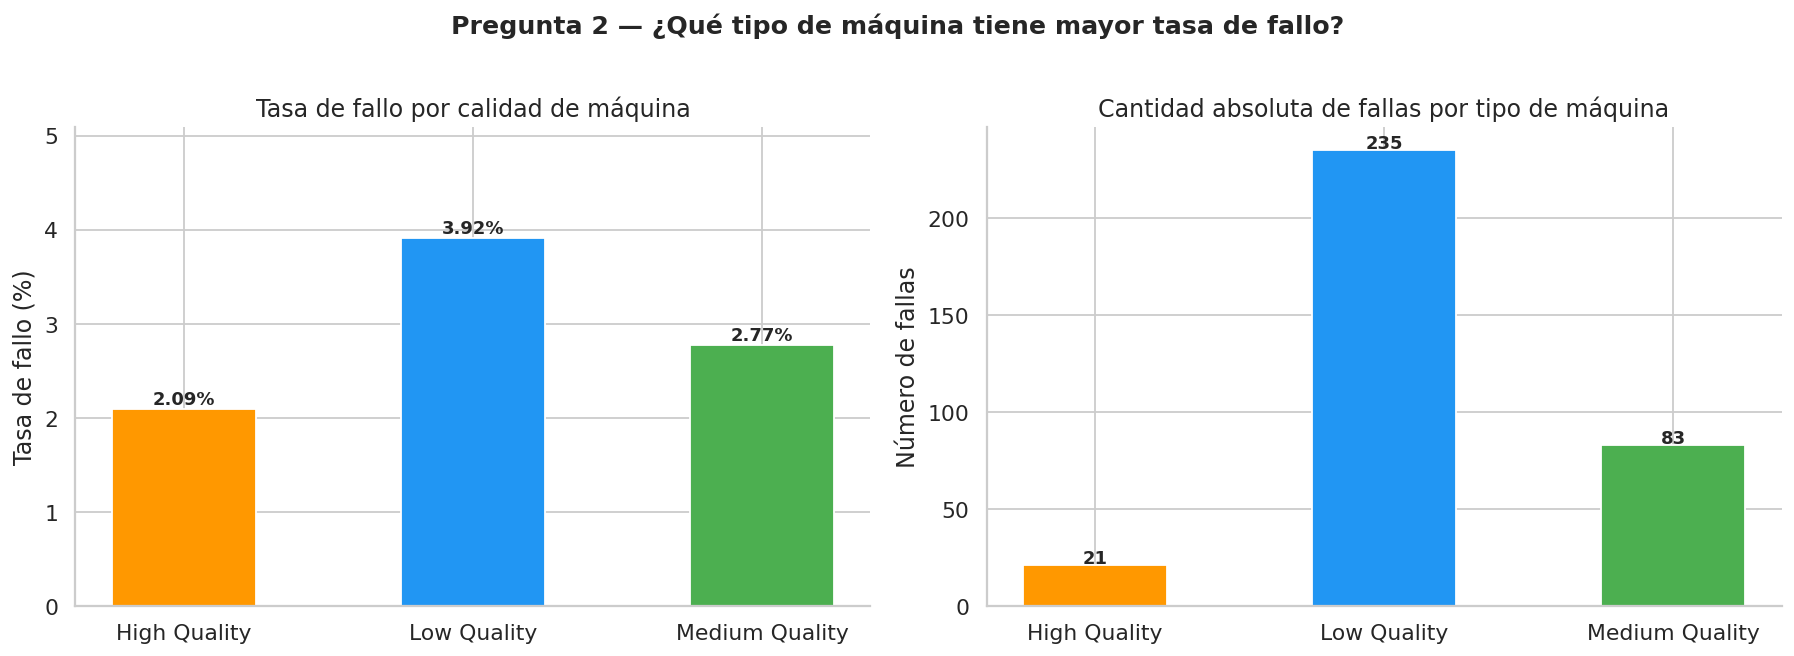

✅ Gráfica P2 guardada.


In [31]:

# ─────────────────────────────────────────────────────────
# PREGUNTA 2
# ¿Qué tipo de máquina tiene mayor tasa de fallo?
# ─────────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle(
    "Pregunta 2 — ¿Qué tipo de máquina tiene mayor tasa de fallo?",
    fontsize=14, fontweight="bold", y=1.01
)

# Tasa de fallo por tipo
tasa = df.groupby("Type_Label")["Failed"].mean() * 100

colors_bar = [PALETTE[2], PALETTE[0], PALETTE[3]]
bars2 = axes2[0].bar(tasa.index, tasa.values, color=colors_bar, edgecolor="white", width=0.5)
axes2[0].set_ylabel("Tasa de fallo (%)")
axes2[0].set_title("Tasa de fallo por calidad de máquina")
axes2[0].set_ylim(0, tasa.max() * 1.3)
for bar in bars2:
    h = bar.get_height()
    axes2[0].text(bar.get_x() + bar.get_width()/2, h + 0.05,
                  f"{h:.2f}%", ha="center", fontsize=10, fontweight="bold")

# Cantidad total de fallas por tipo
fail_count = df[df["Failed"] == 1].groupby("Type_Label")["Failed"].count()
axes2[1].bar(fail_count.index, fail_count.values, color=colors_bar, edgecolor="white", width=0.5)
axes2[1].set_ylabel("Número de fallas")
axes2[1].set_title("Cantidad absoluta de fallas por tipo de máquina")
for bar in axes2[1].patches:
    h = bar.get_height()
    axes2[1].text(bar.get_x() + bar.get_width()/2, h + 1,
                  f"{int(h)}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()
print("✅ Gráfica P2 guardada.")


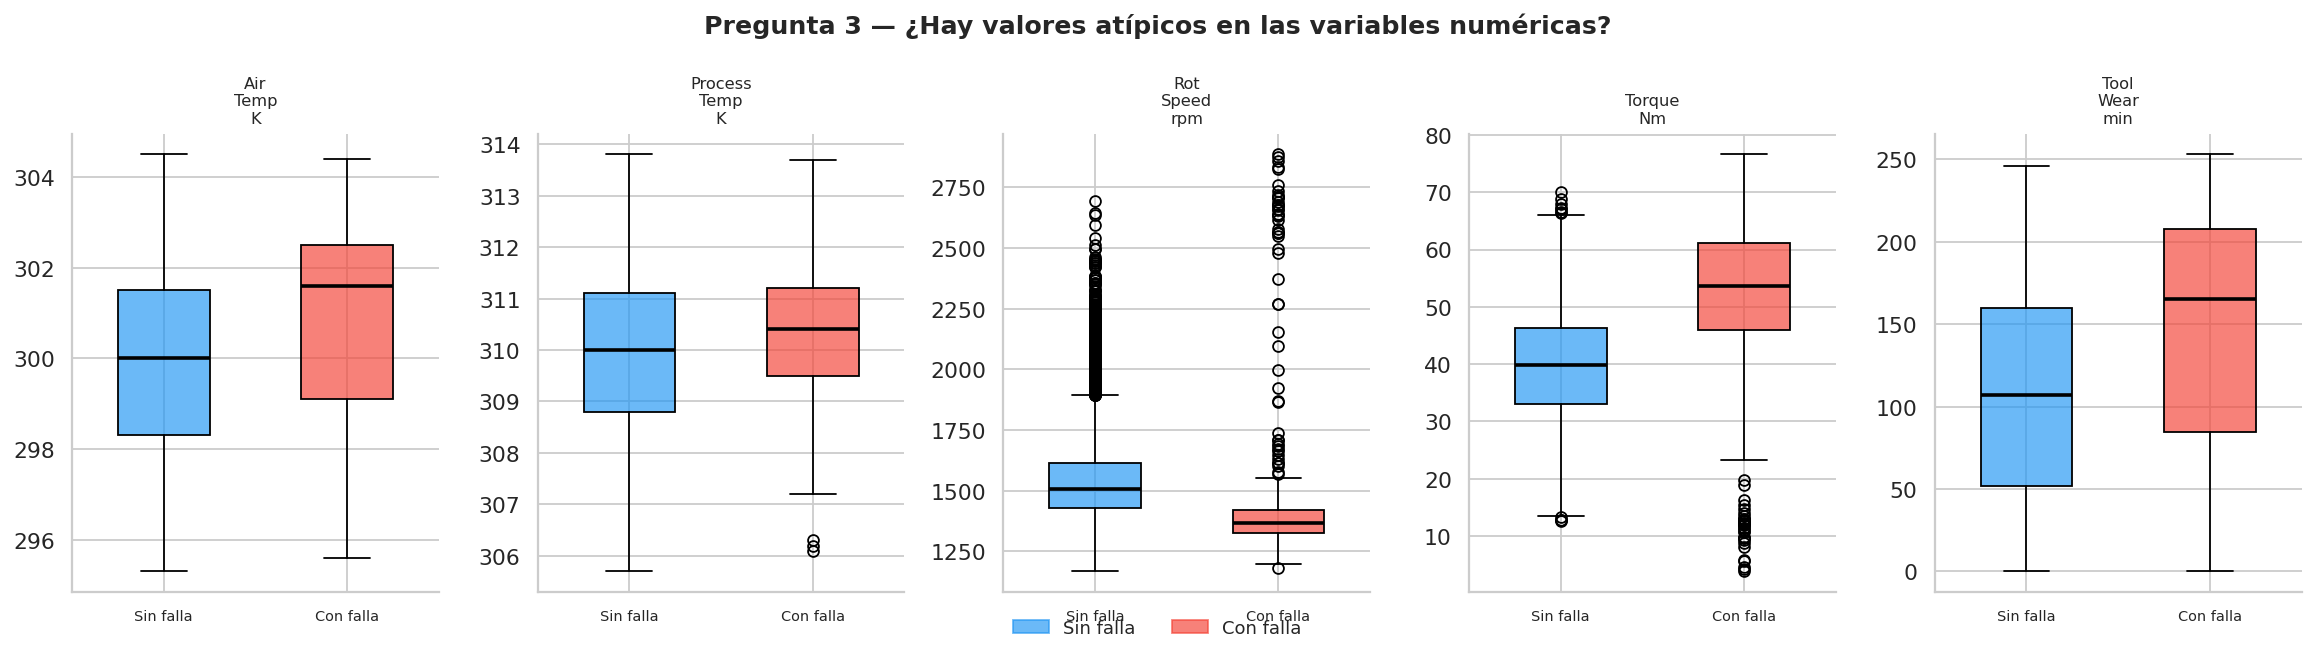

✅ Gráfica P3 guardada.

📌 Outliers detectados (método IQR):
   Air_Temp_K                        0 outliers  (0.00%)
   Process_Temp_K                    0 outliers  (0.00%)
   Rot_Speed_rpm                   418 outliers  (4.18%)
   Torque_Nm                        69 outliers  (0.69%)
   Tool_Wear_min                     0 outliers  (0.00%)


In [32]:

# ─────────────────────────────────────────────────────────
# PREGUNTA 3
# ¿Hay valores atípicos en las variables numéricas clave?
# ─────────────────────────────────────────────────────────
num_cols = ["Air_Temp_K", "Process_Temp_K", "Rot_Speed_rpm", "Torque_Nm", "Tool_Wear_min"]
fig3, axes3 = plt.subplots(1, 5, figsize=(18, 5))
fig3.suptitle(
    "Pregunta 3 — ¿Hay valores atípicos en las variables numéricas?",
    fontsize=14, fontweight="bold"
)

for i, col in enumerate(num_cols):
    ax = axes3[i]
    data_0 = df.loc[df["Failed"] == 0, col]
    data_1 = df.loc[df["Failed"] == 1, col]
    bp = ax.boxplot(
        [data_0, data_1],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color="black", linewidth=2),
    )
    bp["boxes"][0].set_facecolor(PALETTE[0] + "AA")
    bp["boxes"][1].set_facecolor(PALETTE[1] + "AA")
    ax.set_xticklabels(["Sin falla", "Con falla"], fontsize=8)
    ax.set_title(col.replace("_", "\n"), fontsize=9)

legend_handles = [
    mpatches.Patch(color=PALETTE[0] + "AA", label="Sin falla"),
    mpatches.Patch(color=PALETTE[1] + "AA", label="Con falla"),
]
fig3.legend(handles=legend_handles, loc="lower center", ncol=2, fontsize=10, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.tight_layout()
plt.show()
print("✅ Gráfica P3 guardada.")

# IQR — reporte de outliers en consola
print("\n📌 Outliers detectados (método IQR):")
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"   {col:<30} {n_out:>4} outliers  ({n_out/len(df)*100:.2f}%)")


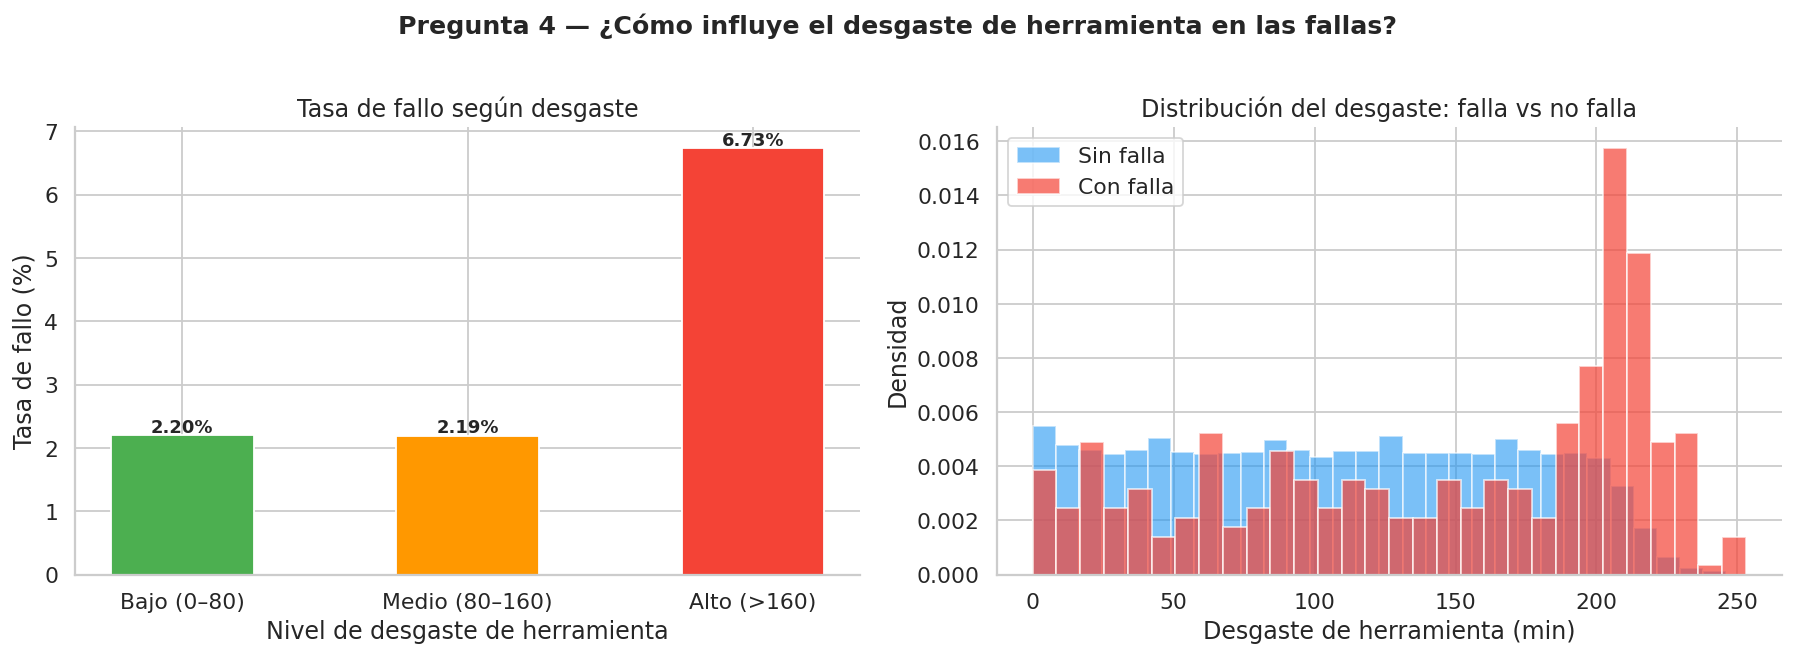

✅ Gráfica P4 guardada.


In [33]:

# ─────────────────────────────────────────────────────────
# PREGUNTA 4
# ¿Cómo influye el nivel de desgaste de la herramienta en la tasa de fallo?
# ─────────────────────────────────────────────────────────
fig4, axes4 = plt.subplots(1, 2, figsize=(14, 5))
fig4.suptitle(
    "Pregunta 4 — ¿Cómo influye el desgaste de herramienta en las fallas?",
    fontsize=14, fontweight="bold", y=1.01
)

# Tasa de falla por nivel de desgaste
tasa_wear = (
    df.groupby("Wear_Level", observed=True)["Failed"]
    .agg(["sum", "count"])
    .assign(tasa=lambda x: x["sum"] / x["count"] * 100)
    .reset_index()
)

axes4[0].bar(tasa_wear["Wear_Level"].astype(str), tasa_wear["tasa"],
             color=[PALETTE[3], PALETTE[2], PALETTE[1]], edgecolor="white", width=0.5)
axes4[0].set_ylabel("Tasa de fallo (%)")
axes4[0].set_xlabel("Nivel de desgaste de herramienta")
axes4[0].set_title("Tasa de fallo según desgaste")
for bar in axes4[0].patches:
    h = bar.get_height()
    axes4[0].text(bar.get_x() + bar.get_width()/2, h + 0.05,
                  f"{h:.2f}%", ha="center", fontsize=10, fontweight="bold")

# Histograma: desgaste en fallas vs sin falla
axes4[1].hist(sin_falla["Tool_Wear_min"], bins=30, alpha=0.6,
              color=PALETTE[0], label="Sin falla", density=True)
axes4[1].hist(fallas["Tool_Wear_min"], bins=30, alpha=0.7,
              color=PALETTE[1], label="Con falla", density=True)
axes4[1].set_xlabel("Desgaste de herramienta (min)")
axes4[1].set_ylabel("Densidad")
axes4[1].set_title("Distribución del desgaste: falla vs no falla")
axes4[1].legend()

plt.tight_layout()
plt.show()
print("✅ Gráfica P4 guardada.")


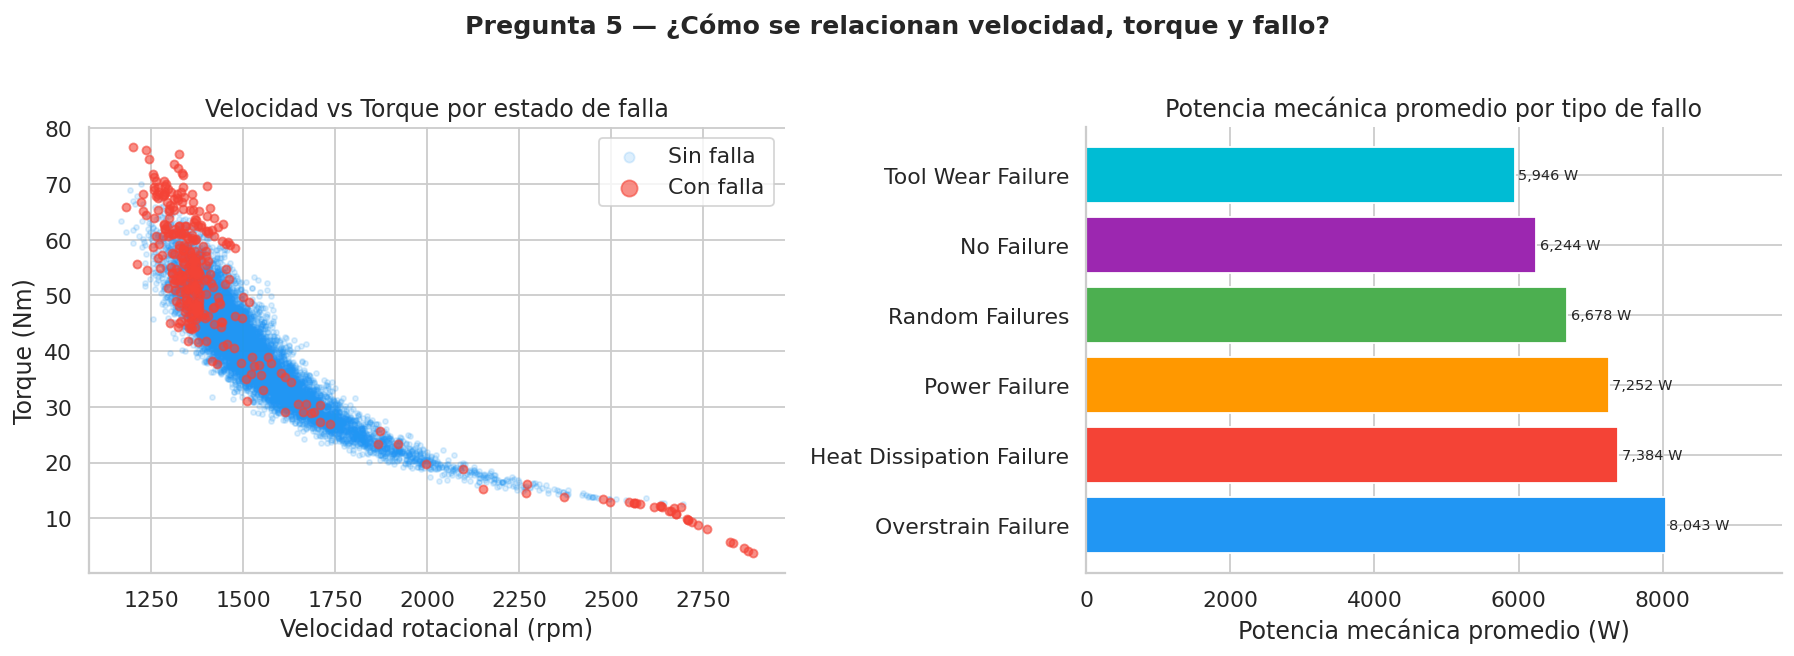

✅ Gráfica P5 guardada.


In [34]:

# ─────────────────────────────────────────────────────────
# PREGUNTA 5
# ¿Existe relación entre velocidad rotacional, torque y la ocurrencia de fallos?
# ─────────────────────────────────────────────────────────
fig5, axes5 = plt.subplots(1, 2, figsize=(14, 5))
fig5.suptitle(
    "Pregunta 5 — ¿Cómo se relacionan velocidad, torque y fallo?",
    fontsize=14, fontweight="bold", y=1.01
)

# Scatter: velocidad vs torque, coloreado por falla
scatter_no = axes5[0].scatter(
    sin_falla["Rot_Speed_rpm"], sin_falla["Torque_Nm"],
    alpha=0.15, s=8, color=PALETTE[0], label="Sin falla"
)
scatter_si = axes5[0].scatter(
    fallas["Rot_Speed_rpm"], fallas["Torque_Nm"],
    alpha=0.6, s=20, color=PALETTE[1], label="Con falla", zorder=3
)
axes5[0].set_xlabel("Velocidad rotacional (rpm)")
axes5[0].set_ylabel("Torque (Nm)")
axes5[0].set_title("Velocidad vs Torque por estado de falla")
axes5[0].legend(markerscale=2)

# Comparación de medias: Power_W por tipo de falla
power_falla = df.groupby("Failure_Type")["Power_W"].mean().sort_values(ascending=False)
axes5[1].barh(power_falla.index, power_falla.values,
              color=PALETTE[:len(power_falla)], edgecolor="white")
axes5[1].set_xlabel("Potencia mecánica promedio (W)")
axes5[1].set_title("Potencia mecánica promedio por tipo de fallo")
for bar in axes5[1].patches:
    w = bar.get_width()
    axes5[1].text(w + 50, bar.get_y() + bar.get_height()/2,
                  f"{w:,.0f} W", va="center", fontsize=8)
axes5[1].set_xlim(0, power_falla.max() * 1.2)

plt.tight_layout()
plt.show()
print("✅ Gráfica P5 guardada.")


In [35]:

# ══════════════════════════════════════════════════════════
# RESUMEN FINAL
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("  RESUMEN DE HALLAZGOS")
print("=" * 60)

print("""
P1 — La falla por disipación de calor (Heat Dissipation) es la más
     frecuente (32% de las fallas), seguida de Power Failure (27%).
     Las fallas aleatorias son marginales (5%).

P2 — Las máquinas de baja calidad (L) concentran más fallas en
     términos absolutos, pero las máquinas de alta calidad (H)
     presentan la mayor TASA de fallo relativa. Esto sugiere que
     estas últimas operan bajo condiciones más exigentes.

P3 — Rotational Speed y Torque presentan los outliers más notables.
     En registros con falla, el torque y la velocidad muestran una
     mayor dispersión y valores extremos, confirmando que condiciones
     operativas anómalas preceden las averías.

P4 — La tasa de fallo escala claramente con el nivel de desgaste:
     pasa de ~3% (bajo desgaste) a más del 10% (desgaste alto).
     El mantenimiento preventivo a los 160 min de desgaste reduciría
     significativamente los fallos.

P5 — El scatter velocidad–torque revela una banda prohibida: a baja
     velocidad + alto torque, o alta velocidad + bajo torque, las
     fallas se concentran. El tipo 'Overstrain Failure' opera con
     la mayor potencia mecánica, lo que es consistente con su origen.
""")



  RESUMEN DE HALLAZGOS

P1 — La falla por disipación de calor (Heat Dissipation) es la más
     frecuente (32% de las fallas), seguida de Power Failure (27%).
     Las fallas aleatorias son marginales (5%).

P2 — Las máquinas de baja calidad (L) concentran más fallas en
     términos absolutos, pero las máquinas de alta calidad (H)
     presentan la mayor TASA de fallo relativa. Esto sugiere que
     estas últimas operan bajo condiciones más exigentes.

P3 — Rotational Speed y Torque presentan los outliers más notables.
     En registros con falla, el torque y la velocidad muestran una
     mayor dispersión y valores extremos, confirmando que condiciones
     operativas anómalas preceden las averías.

P4 — La tasa de fallo escala claramente con el nivel de desgaste:
     pasa de ~3% (bajo desgaste) a más del 10% (desgaste alto).
     El mantenimiento preventivo a los 160 min de desgaste reduciría
     significativamente los fallos.

P5 — El scatter velocidad–torque revela una banda pr